In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import re
import numpy as np
import json
import urllib.request 
import glob
pd.set_option('display.max_rows', 200)
# to keep my paths secret
import xscen as xs
from xscen import CONFIG
xs.load_config('paths.yml', verbose=(__name__ == '__main__'), reset=True)

In [6]:
m={
    'areacella': 'Grid-cell area for atmospheric grid variables',
    'areacello': 'Grid-cell area for ocean variables',
    'clt': 'Total cloud cover percentage',
    'deptho': 'Sea floor depth below geoid',
    'evspsbl': 'Evaporation including sublimation and transpiration',
    'hfls': 'Surface upward latent heat flux',
    'hfss': 'Surface upward sensible heat flux',
    'hur': 'Relative humidity',
    'hurs': 'Near-surface relative humidity',
    'hus': 'Specific humidity',
    'huss': 'Near-surface specific humidity',
    'mrro': 'Total runoff',
    'mrros': 'Surface runoff flux',
    'mrsofc': 'Capacity of soil to store water',
    'mrsos': 'Moisture in upper portion of soil column',
    'orog': 'Surface altitude',
    'pr': 'Precipitation',
    'prsn': 'Snowfall flux',
    'prw': 'Atmosphere water vapour content',
    'ps': 'Surface air pressure',
    'psl': 'Sea level pressure',
    'rlds': 'Surface downwelling longwave radiation',
    'rlus': 'Surface upwelling longwave radiation',
    'rlut': 'TOA outgoing longwave radiation',
    'rlutcs': 'TOA outgoing longwave flux assuming clear sky',
    'rsds': 'Surface downwelling shortwave radiation',
    'rsdt': 'TOA incident shortwave radiation',
    'rsus': 'Surface upwelling shortwave radiation',
    'rsut': 'TOA outgoing shortwave radiation',
    'rsutcs': 'TOA outgoing shortwave flux assuming clear sky',
    'sfcWind': 'Near-surface wind speed',
    'sfcWindmax': 'Daily maximum near-surface wind speed',
    'sftgif': 'Land ice area percentage',
    'sftlf': 'Percentage of the grid cell occupied by land including lakes',
    'sftof': 'Sea area percentage',
    'siconc': 'Sea-ice area percentage on ocean grid',
    'simass': 'Sea-ice mass per area',
    'sitemptop': 'Surface temperature of sea ice',
    'sithick': 'Sea ice thickness',
    'snd': 'Snow depth',
    'snw': 'Surface snow amount',
    'sos': 'Sea surface salinity',
    'ta': 'Air temperature',
    'tas': 'Near-surface air temperature',
    'tasmax': 'Daily maximum near-surface air temperature',
    'tasmin': 'Daily minimum near-surface air temperature',
    'tauu': 'Surface downward eastward wind stress',
    'tauv': 'Surface downward northward wind stress',
    'tos': 'Sea surface temperature',
    'ts': 'Surface temperature',
    'ua': 'Eastward wind',
    'uas': 'Eastward near-surface wind',
    'va': 'Northward wind',
    'vas': 'Northward near-surface wind',
    'zg': 'Geopotential height',
    'zos': 'Sea surface height above geoid'
}
mapping_var = {v: k for k, v in m.items()}

# old CDS

In [52]:
df_old=pd.read_csv(f"{CONFIG['dir']}/copernicus/user_stats_for_CMIP/01_Old_CDS_users_and_request_by_adaptor_full.csv")
# filter method, adaptor.esgf_wps.retrieve (CMIP6, IPCC Atlas, C3S Alas, DCPP data)
df_old=df_old[df_old['Method']=='adaptor.esgf_wps.retrieve']
# remove request to API of impossible data
df_old=df_old[~df_old['variable'].isnull()]
df_old=df_old[~df_old['variable'].str.contains(' ')]
df_old=df_old[~df_old['variable'].str.contains('-')]
# Boolean mask: True if no uppercase letter in the row
mask = ~df_old.applymap(lambda x: any(c.isupper() for c in str(x))).any(axis=1)
df_old = df_old[mask]

# # cop_long_name=["Air temperature", "Capacity of soil to store water", "Daily maximum near-surface air temperature", "Daily minimum near-surface air temperature", "Eastward near-surface wind", "Eastward wind", "Evaporation including sublimation and transpiration", "Geopotential height", "Grid-cell area for atmospheric grid variables", "Grid-cell area for ocean variables", "Land ice area percentage", "Moisture in upper portion of soil column", "Near-surface air temperature", "Near-surface relative humidity", "Near-surface specific humidity", "Near-surface wind speed", "Northward near-surface wind", "Northward wind", "Percentage of the grid cell occupied by land including lakes", "Precipitation", "Relative humidity", "Sea area percentage", "Sea floor depth below geoid", "Sea ice thickness", "Sea level pressure", "Sea surface height above geoid", "Sea surface salinity", "Sea surface temperature", "Sea-ice area percentage on ocean grid", "Sea-ice mass per area", "Snow depth", "Snowfall flux", "Specific humidity", "Surface air pressure", "Surface altitude", "Surface downward eastward wind stress", "Surface downward northward wind stress", "Surface downwelling longwave radiation", "Surface downwelling shortwave radiation", "Surface snow amount", "Surface temperature", "Surface temperature of sea ice", "Surface upward latent heat flux", "Surface upward sensible heat flux", "Surface upwelling longwave radiation", "Surface upwelling shortwave radiation", "TOA incident shortwave radiation", "TOA outgoing longwave radiation", "TOA outgoing shortwave radiation", "Total cloud cover percentage", "Total runoff"]
# #cop_code=[x.lower().replace(' ','_').replace('-','_') for x in cop_long_name]
# df_old=df_old[df_old['variable'].isin(mapping_var)]
df_old['clean_var']=[str(v).replace('near_surface', 'near-surface'
                               ).replace('grid_cell', 'grid-cell'
                                        ).replace('sea_ice', 'sea-ice').replace('_', ' ').capitalize() for v in df_old['variable']]
df_old['variable_code']= [mapping_var[v] if v in mapping_var else np.nan for v in df_old['clean_var'] ]
df_old=df_old[~df_old['variable_code'].isnull()]
df_old=df_old.sort_values('Requests', ascending=False)
df_old

/tmp/ipykernel_122049/3884910785.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


,Method,variable,Users,Requests,Volume,clean_var,variable_code
1264,adaptor.esgf_wps.retrieve,precipitation,865,220376,2909.17,Precipitation,pr
1170,adaptor.esgf_wps.retrieve,near_surface_air_temperature,435,64374,1883.17,Near-surface air temperature,tas
662,adaptor.esgf_wps.retrieve,daily_maximum_near_surface_air_temperature,418,33401,1692.74,Daily maximum near-surface air temperature,tasmax
664,adaptor.esgf_wps.retrieve,daily_minimum_near_surface_air_temperature,286,16224,1017.86,Daily minimum near-surface air temperature,tasmin
1181,adaptor.esgf_wps.retrieve,near_surface_specific_humidity,115,14607,693.99,Near-surface specific humidity,huss
1187,adaptor.esgf_wps.retrieve,near_surface_wind_speed,205,14208,635.55,Near-surface wind speed,sfcWind
744,adaptor.esgf_wps.retrieve,evaporation_including_sublimation_and_transpir...,66,5528,48.22,Evaporation including sublimation and transpir...,evspsbl
493,adaptor.esgf_wps.retrieve,air_temperature,183,5494,133.98,Air temperature,ta
1678,adaptor.esgf_wps.retrieve,surface_temperature,82,5343,23.72,Surface temperature,ts
1859,adaptor.esgf_wps.retrieve,total_runoff,40,4989,16.58,Total runoff,mrro


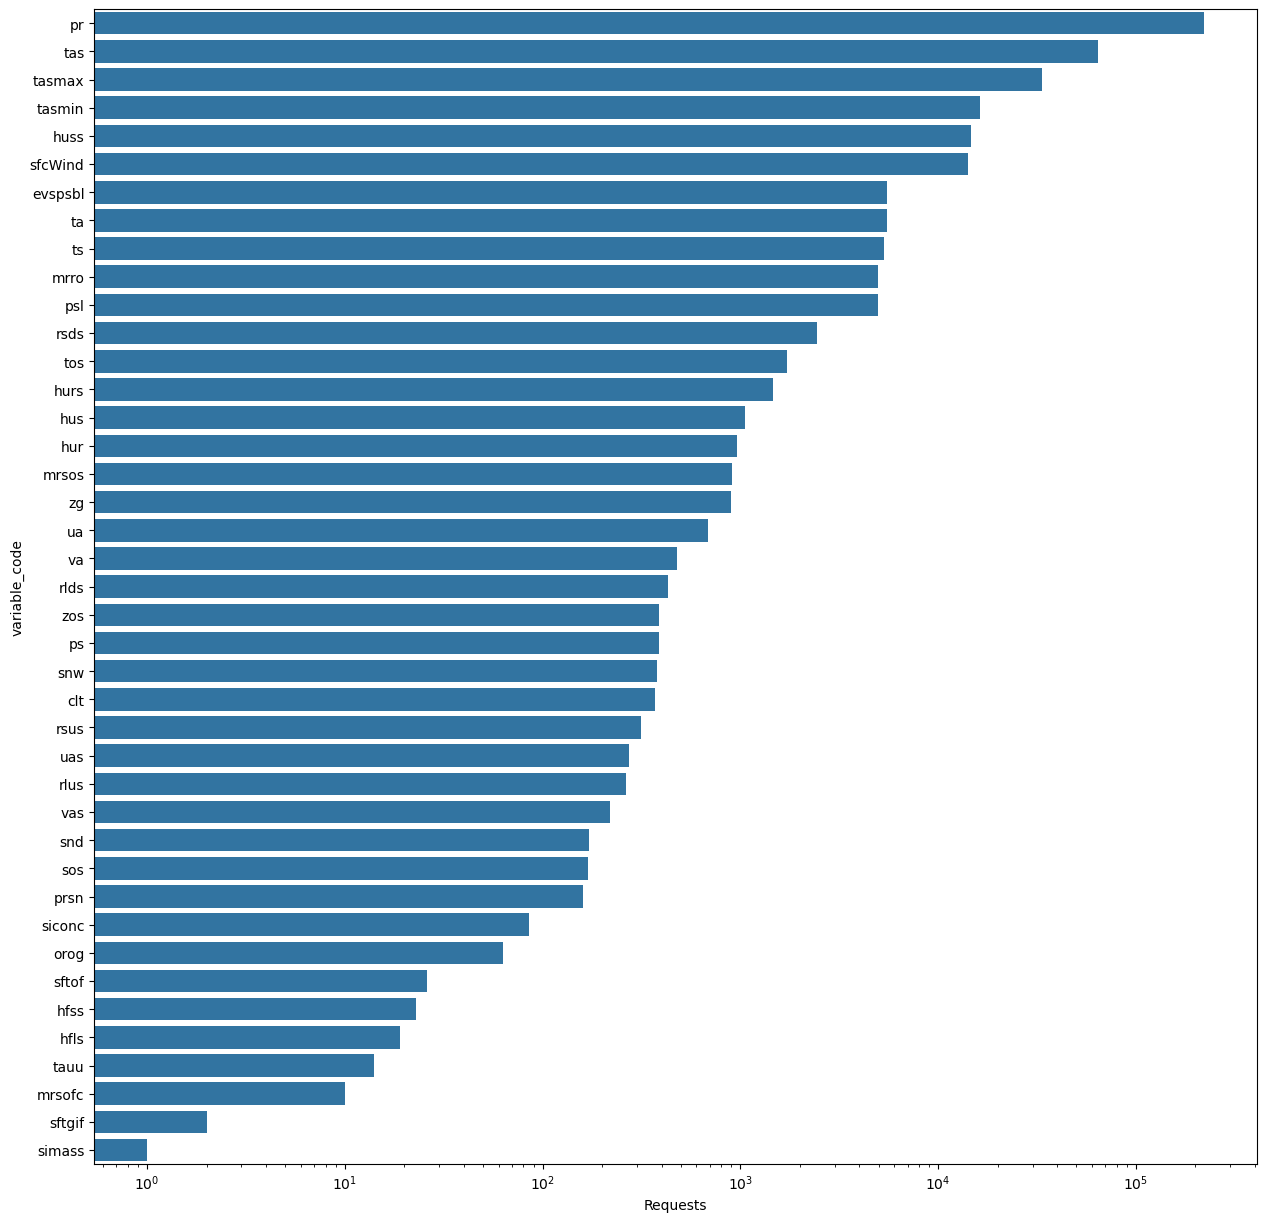

In [53]:
plt.figure(figsize=(15,15))
ax=sns.barplot(x='Requests', y='variable_code',data=df_old)
ax.set_xscale('log')

# new CDS

In [72]:
df_new=pd.read_csv(f"{CONFIG['dir']}/copernicus/user_stats_for_CMIP/06_New_CDS_CMIP6_requests_by_variable.csv")
df_new=df_new.rename(columns={'requests': 'Requests'})

# filter method, adaptor.esgf_wps.retrieve (CMIP6, IPCC Atlas, C3S Alas, DCPP data)
#df=df[df['Method']=='adaptor.esgf_wps.retrieve']
# remove request to API of impossible data
df_new=df_new[~df_new['variable'].isnull()]
df_new=df_new[~df_new['variable'].str.contains(' ')]
df_new=df_new[~df_new['variable'].str.contains('-')]
# Boolean mask: True if no uppercase letter in the row
mask = ~df_new.applymap(lambda x: any(c.isupper() for c in str(x))).any(axis=1)
df_new = df_new[mask]


df_new['clean_var']=[str(v).replace('near_surface', 'near-surface'
                               ).replace('grid_cell', 'grid-cell'
                                        ).replace('sea_ice', 'sea-ice').replace('_', ' ').capitalize() for v in df_new['variable']]
df_new['variable_code']= [mapping_var[v] if v in mapping_var else np.nan for v in df_new['clean_var'] ]
df_new=df_new[~df_new['variable_code'].isnull()]
df_new=df_new.sort_values('Requests', ascending=False)
df_new

/tmp/ipykernel_122049/3394078461.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


,variable,Requests,users,clean_var,variable_code
0,precipitation,9007,49,Precipitation,pr
1,daily_maximum_near_surface_air_temperature,8465,24,Daily maximum near-surface air temperature,tasmax
2,daily_minimum_near_surface_air_temperature,8448,21,Daily minimum near-surface air temperature,tasmin
3,surface_downwelling_shortwave_radiation,989,4,Surface downwelling shortwave radiation,rsds
4,surface_upwelling_shortwave_radiation,973,2,Surface upwelling shortwave radiation,rsus
5,near_surface_air_temperature,788,37,Near-surface air temperature,tas
6,total_runoff,377,8,Total runoff,mrro
7,eastward_wind,367,5,Eastward wind,ua
8,specific_humidity,365,3,Specific humidity,hus
9,evaporation_including_sublimation_and_transpir...,339,6,Evaporation including sublimation and transpir...,evspsbl


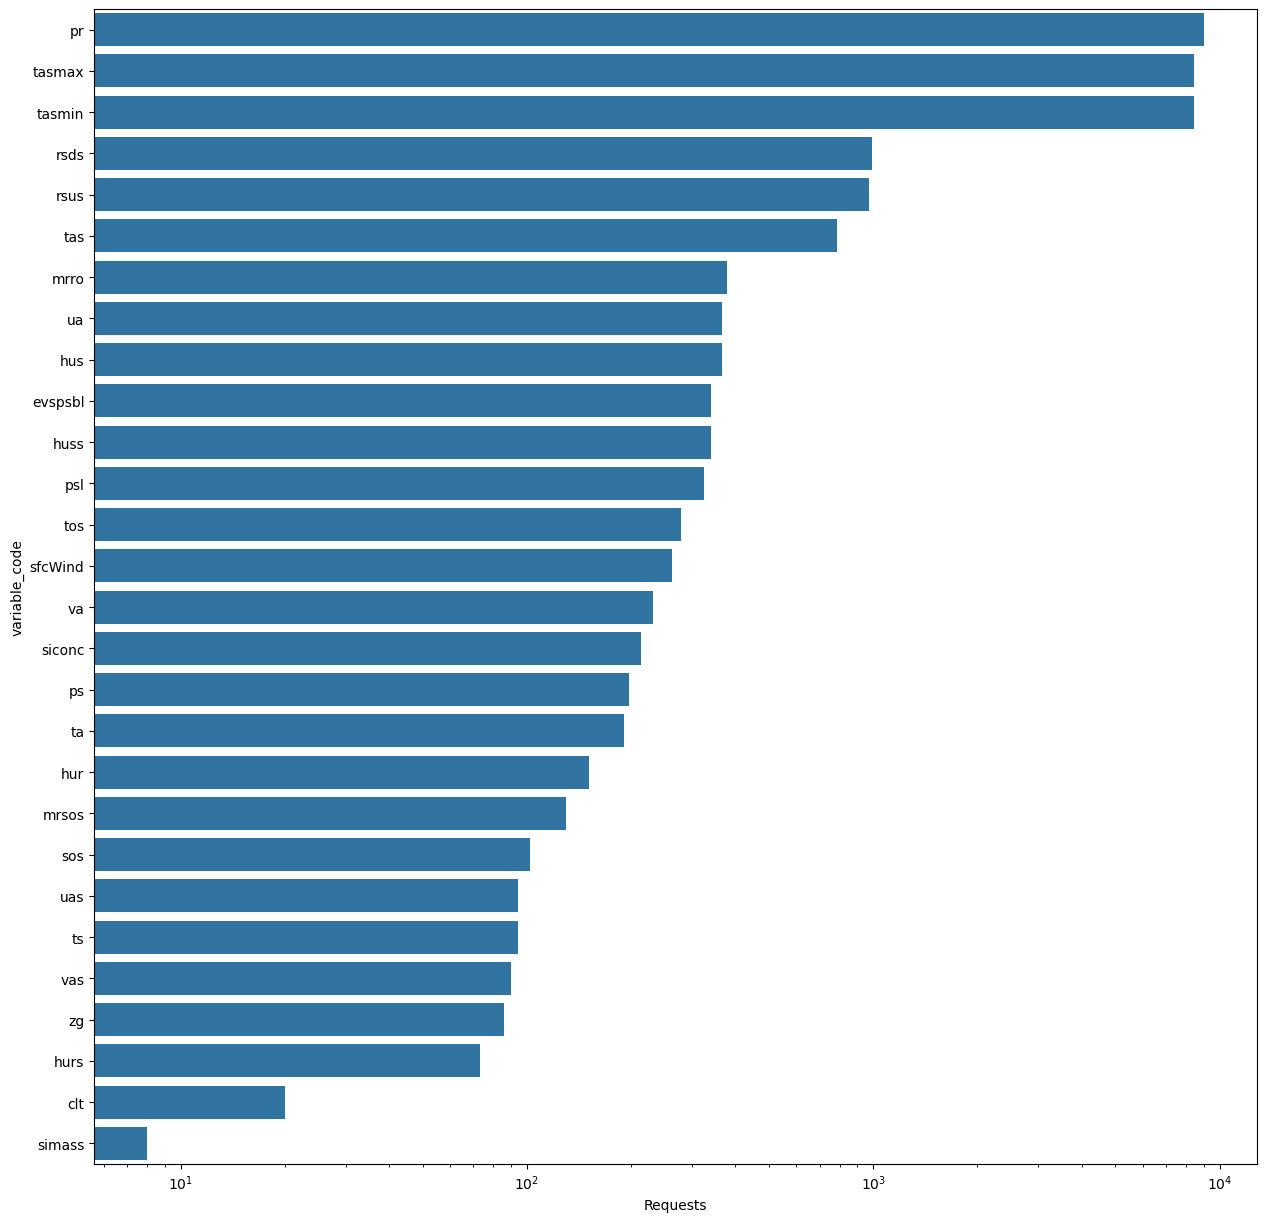

In [74]:
plt.figure(figsize=(15,15))
ax=sns.barplot(x='Requests', y='variable_code',data=df_new)
ax.set_xscale('log')

In [80]:
merged = pd.merge(df_old, df_new, on="variable_code", how="outer", suffixes=("_old", "_new"))
merged["Requests_sum"] = merged[["Requests_old", "Requests_new"]].fillna(0).sum(axis=1)
merged=merged.sort_values('Requests_sum', ascending=False)
merged

,Method,variable_old,Users,Requests_old,Volume,clean_var_old,variable_code,variable_new,Requests_new,users,clean_var_new,Requests_sum
12,adaptor.esgf_wps.retrieve,precipitation,865,220376,2909.17,Precipitation,pr,precipitation,9007.0,49.0,Precipitation,229383.0
29,adaptor.esgf_wps.retrieve,near_surface_air_temperature,435,64374,1883.17,Near-surface air temperature,tas,near_surface_air_temperature,788.0,37.0,Near-surface air temperature,65162.0
30,adaptor.esgf_wps.retrieve,daily_maximum_near_surface_air_temperature,418,33401,1692.74,Daily maximum near-surface air temperature,tasmax,daily_maximum_near_surface_air_temperature,8465.0,24.0,Daily maximum near-surface air temperature,41866.0
31,adaptor.esgf_wps.retrieve,daily_minimum_near_surface_air_temperature,286,16224,1017.86,Daily minimum near-surface air temperature,tasmin,daily_minimum_near_surface_air_temperature,8448.0,21.0,Daily minimum near-surface air temperature,24672.0
7,adaptor.esgf_wps.retrieve,near_surface_specific_humidity,115,14607,693.99,Near-surface specific humidity,huss,near_surface_specific_humidity,339.0,10.0,Near-surface specific humidity,14946.0
20,adaptor.esgf_wps.retrieve,near_surface_wind_speed,205,14208,635.55,Near-surface wind speed,sfcWind,near_surface_wind_speed,263.0,15.0,Near-surface wind speed,14471.0
1,adaptor.esgf_wps.retrieve,evaporation_including_sublimation_and_transpir...,66,5528,48.22,Evaporation including sublimation and transpir...,evspsbl,evaporation_including_sublimation_and_transpir...,339.0,6.0,Evaporation including sublimation and transpir...,5867.0
28,adaptor.esgf_wps.retrieve,air_temperature,183,5494,133.98,Air temperature,ta,air_temperature,191.0,8.0,Air temperature,5685.0
34,adaptor.esgf_wps.retrieve,surface_temperature,82,5343,23.72,Surface temperature,ts,surface_temperature,94.0,5.0,Surface temperature,5437.0
8,adaptor.esgf_wps.retrieve,total_runoff,40,4989,16.58,Total runoff,mrro,total_runoff,377.0,8.0,Total runoff,5366.0


Text(0, 0.5, 'Variables')

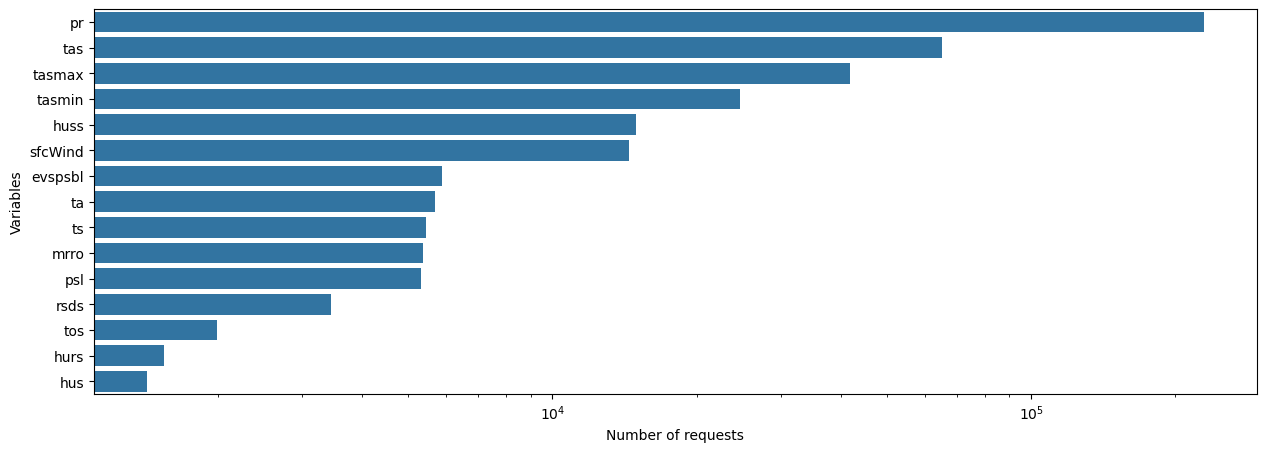

In [84]:
n=15
plt.figure(figsize=(15,5))
ax=sns.barplot(x='Requests_sum', y='variable_code',data=merged[:n])
ax.set_xscale('log')
ax.set_xlabel('Number of requests')
ax.set_ylabel('Variables')